# NB05 — EDO-Estado: Acoplamiento Morfológico, Contexto Dinámico y Trayectorias Nocturnas

**Pipeline:** PAC_v2 · Gold v1.2  
**Depende de:** NB01 (morfotipos), NB03 (gold/nights + night_features), NB04 (event_states_multiscale, night_multiscale_features)

### Objetivo

Integrar la dimensión temporal-contextual del evento (¿en qué estado PAC ocurrió?)
con la dimensión morfológica (¿qué morfotipo generó?), la fisiología del evento y
la trayectoria nocturna del paciente.

### Salidas Gold
- `gold/transition_matrices.parquet` — matrices de transición Markov por escala
- `gold/night_multiscale_features.parquet` — actualizado con coupling_index, pct_severe, cluster

### Figuras
- `05A_01` P(morfotipo | estado PAC)   · `05A_02` P(estado | morfotipo)
- `05A_03` Perfil fisiológico EDO×estado · `05A_04` Índice de acoplamiento
- `05B_01` Matrices Markov              · `05B_02` Contexto pre/durante/post
- `05B_03` Riesgo relativo por estado   · `05B_04` Resiliencia post-evento
- `05B_05` Trayectorias nocturnas PCA

## Diseño conceptual

### Motivación
NB01–NB03 construyeron la fenotipia de los EDOs (morfotipos C1–C5) y los índices nocturnos.
NB04 construyó los estados PAC en tres escalas temporales (S/M/L) y los correlacionó con métricas.

Este notebook agrega la pregunta: **¿el contexto dinámico en que ocurre el evento predice su morfotipo y su severidad?**

### Bloques
- **BLOQUE A** — Distribución condicional (qué morfotipo ocurre en qué estado)
- **BLOQUE B** — Dinámica Markoviana y trayectorias nocturnas

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
from scipy.stats import chi2_contingency, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from numpy.linalg import eig
from pathlib import Path

ROOT  = Path('..')              # notebooks/ → PAC_v2/
GOLD  = ROOT / 'gold'
FIGDIR = Path('figuras')
FIGDIR.mkdir(exist_ok=True)

MORPH_COLORS = {'C1':'#4878CF','C2':'#6ACC65','C3':'#D65F5F','C4':'#B47CC7','C5':'#C4AD66'}
CMAP_HEAT    = 'Blues'
MORPHS       = ['C1','C2','C3','C4','C5']
SCALES       = {'s':'state_s_label','m':'state_m_label','l':'state_l_label'}
SCALE_LABELS = {'s':'S-scale (30 s)','m':'M-scale (5 min)','l':'L-scale (30 min)'}

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':150})

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGDIR / name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → {FIGDIR / name}')

print(f"GOLD : {GOLD.resolve()}")
print("Setup completo ✓")

GOLD : /Users/ri1965/Proyectos/PAC_v2/gold
Setup completo ✓


## Carga de datos

In [2]:
esm_raw  = pd.read_parquet(GOLD / 'event_states_multiscale.parquet')
nmf      = pd.read_parquet(GOLD / 'night_multiscale_features.parquet')
nights   = pd.read_parquet(GOLD / 'nights.parquet')
states_raw = pd.read_parquet(GOLD / 'states.parquet')

# Filtrar cohort estricto (in_strict) y normalizar nombre de morfotipo
esm = esm_raw[esm_raw['in_strict'] == True].copy()
esm = esm.rename(columns={'morphotype_curve': 'morph'})

# Asegurar que los estados de las 3 escalas estén asignados
for sc_col in ['state_s_label', 'state_m_label', 'state_l_label']:
    esm = esm[esm[sc_col].notna()]

esm['is_severe_morph'] = esm['morph'].isin(['C4', 'C5'])
esm = esm.sort_values(['night_record_id', 'ts_start']).reset_index(drop=True)

# nmf: agregar aasm_sev desde night_sev si no existe (debe existir desde NB04)
if 'aasm_sev' not in nmf.columns:
    nmf['aasm_sev'] = pd.cut(nmf['ahi_3'], bins=[-1,5,15,30,999],
                              labels=['Normal','Leve','Moderado','Severo'])

print(f"ESM cohort in_strict : {len(esm):,} eventos | {esm['user_id'].nunique()} pacientes")
print(f"Morfotipos: {dict(esm['morph'].value_counts())}")
print(f"Eventos severos: {esm['is_severe_morph'].sum():,} ({esm['is_severe_morph'].mean()*100:.2f}%)")
print(f"NMF noches: {len(nmf)}")
print(f"Severidad AASM:\n{nmf['aasm_sev'].value_counts().sort_index().to_string()}")

ESM cohort in_strict : 80,353 eventos | 12 pacientes
Morfotipos: {'C1': np.int64(52275), 'C2': np.int64(20079), 'C4': np.int64(3940), 'C3': np.int64(3389), 'C5': np.int64(662)}
Eventos severos: 4,602 (5.73%)
NMF noches: 560
Severidad AASM:
aasm_sev
Normal       41
Leve        334
Moderado    160
Severo       25


---
## BLOQUE A — Distribución Condicional

### Sección A1 — P(morfotipo | estado PAC) — matrices de probabilidad condicional

S-scale (30 s): chi2=40364.8, p=0.00e+00, V=0.354
M-scale (5 min): chi2=17015.8, p=0.00e+00, V=0.230
L-scale (30 min): chi2=9264.1, p=0.00e+00, V=0.196


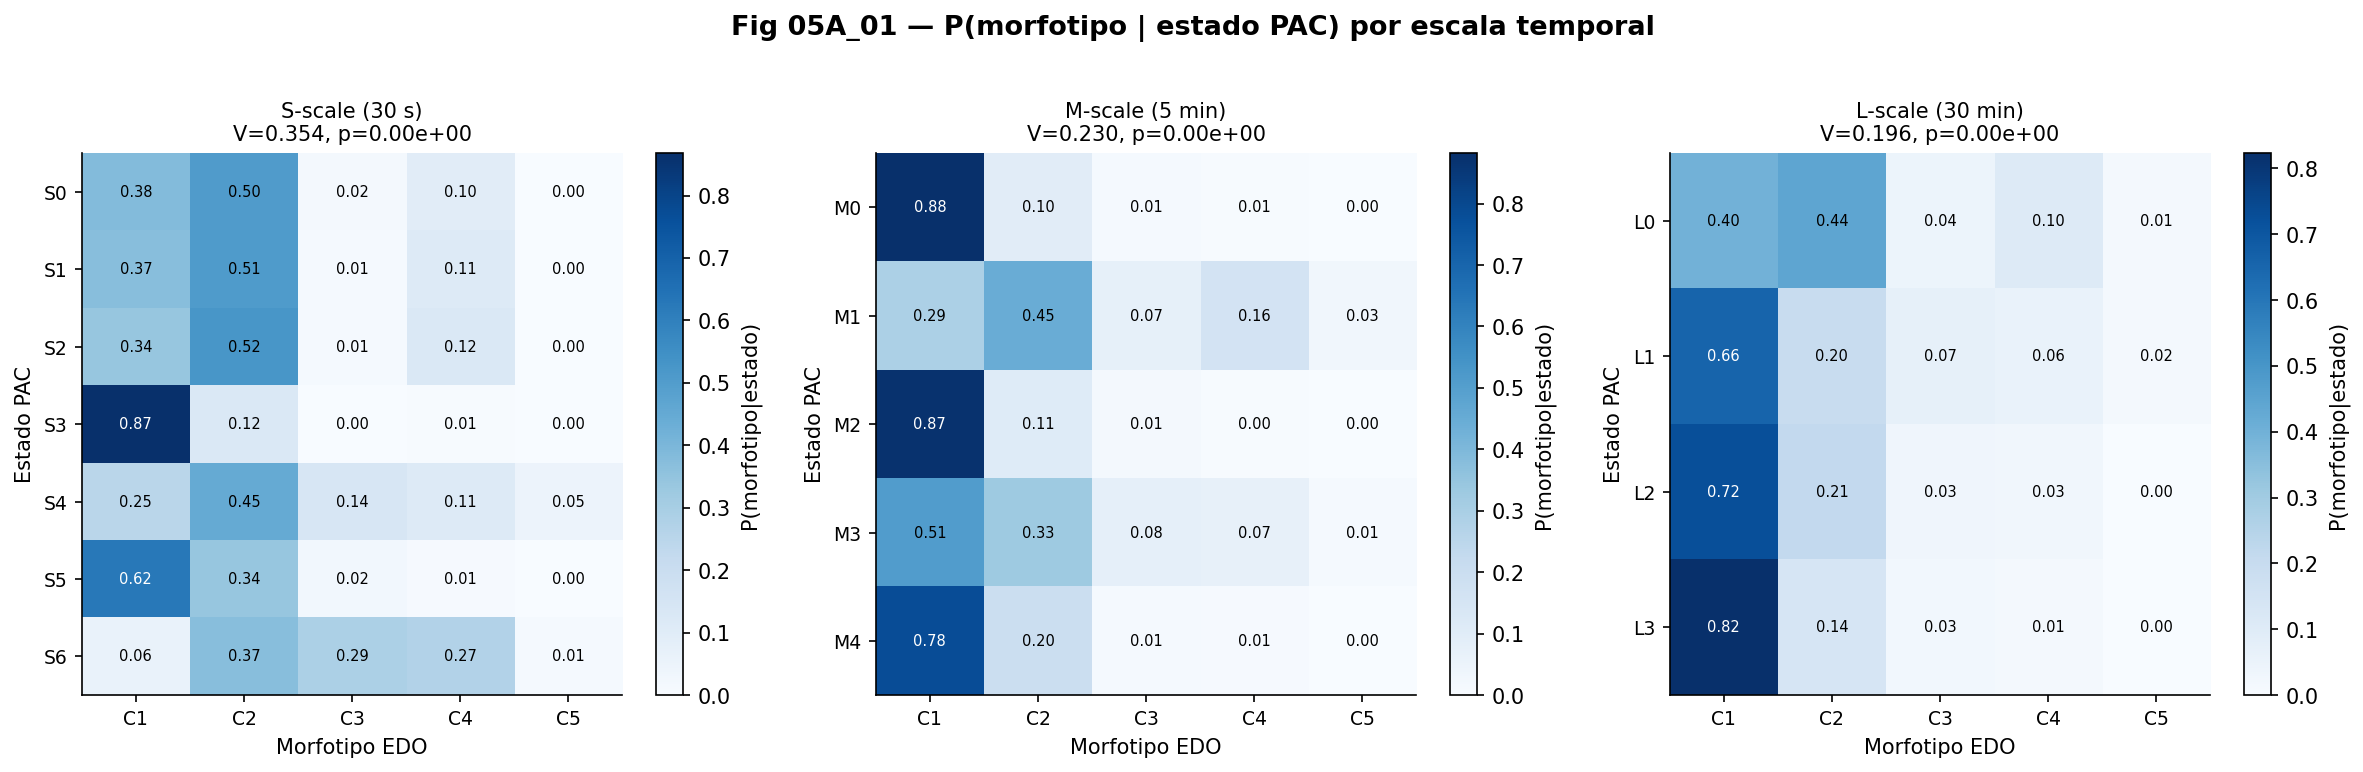

  → figuras/05A_01_prob_morph_dado_estado.png


In [3]:
# A1: P(morfotipo | estado PAC) — 3 escalas
a1_results = {}
for sc, col in SCALES.items():
    ct = pd.crosstab(esm[col], esm['morph']).reindex(columns=MORPHS, fill_value=0)
    prob = ct.div(ct.sum(axis=1), axis=0)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    a1_results[sc] = {'ct': ct, 'prob': prob, 'chi2': chi2, 'p': p, 'cramers_v': cramers_v}
    print(f"{SCALE_LABELS[sc]}: chi2={chi2:.1f}, p={p:.2e}, V={cramers_v:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fig 05A_01 — P(morfotipo | estado PAC) por escala temporal",
             fontsize=13, fontweight='bold', y=1.02)
for ax, (sc, col) in zip(axes, SCALES.items()):
    r = a1_results[sc]; prob = r['prob']
    states_order = sorted(prob.index, key=lambda x: int(x[1:]))
    prob_ord = prob.loc[states_order]
    im = ax.imshow(prob_ord.values, cmap=CMAP_HEAT, aspect='auto',
                   vmin=0, vmax=prob_ord.values.max())
    ax.set_xticks(range(len(MORPHS)));      ax.set_xticklabels(MORPHS, fontsize=9)
    ax.set_yticks(range(len(states_order))); ax.set_yticklabels(states_order, fontsize=9)
    ax.set_xlabel("Morfotipo EDO"); ax.set_ylabel("Estado PAC")
    ax.set_title(f"{SCALE_LABELS[sc]}\nV={r['cramers_v']:.3f}, p={r['p']:.2e}", fontsize=10)
    plt.colorbar(im, ax=ax, label='P(morfotipo|estado)')
    for i in range(len(states_order)):
        for j in range(len(MORPHS)):
            val = prob_ord.values[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if val > 0.55 else 'black')
savefig('05A_01_prob_morph_dado_estado.png')

### Sección A2 — P(estado | morfotipo) — distribución inversa

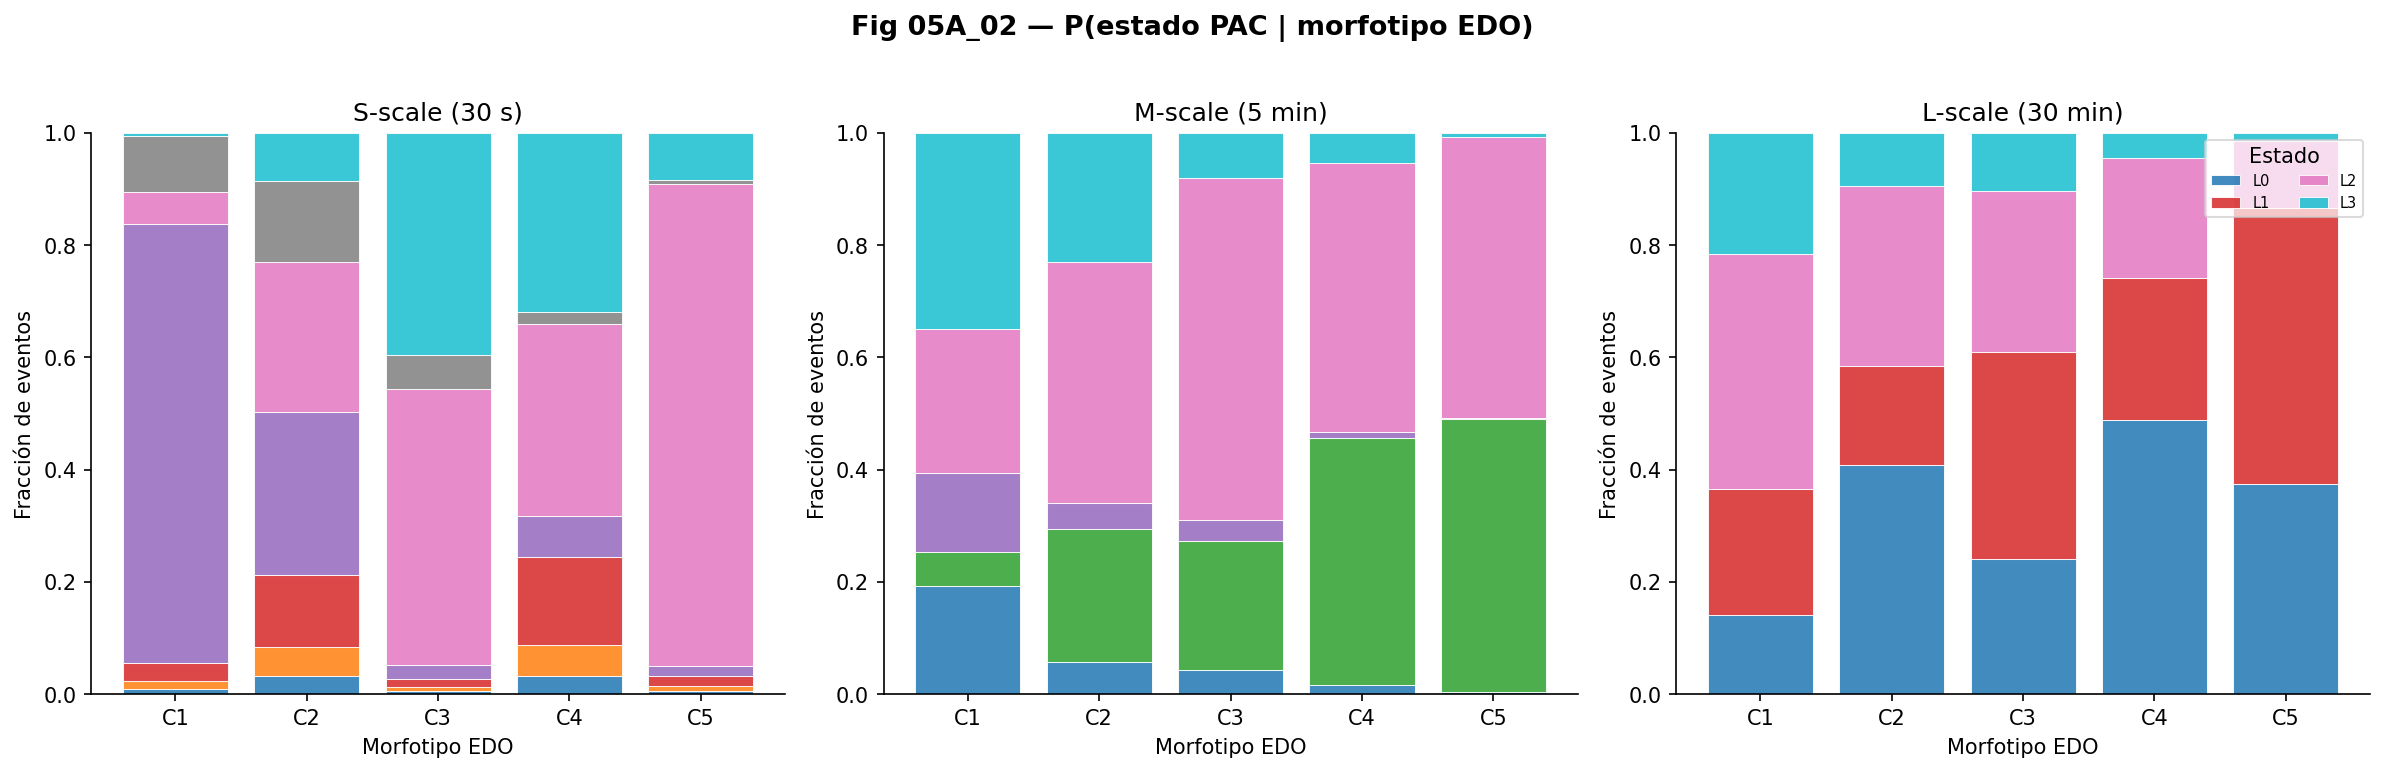

  → figuras/05A_02_prob_estado_dado_morph.png


In [4]:
# A2: P(estado | morfotipo)
a2_results = {}
for sc, col in SCALES.items():
    ct = pd.crosstab(esm['morph'], esm[col])
    states_sorted = sorted(ct.columns, key=lambda x: int(x[1:]))
    ct = ct[states_sorted]
    a2_results[sc] = {'ct': ct, 'prob': ct.div(ct.sum(axis=1), axis=0)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fig 05A_02 — P(estado PAC | morfotipo EDO)",
             fontsize=13, fontweight='bold', y=1.02)
for ax, (sc, col) in zip(axes, SCALES.items()):
    prob = a2_results[sc]['prob']
    states_ord = sorted(prob.columns, key=lambda x: int(x[1:]))
    prob = prob[states_ord]; bottom = np.zeros(len(MORPHS))
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(states_ord)))
    for j, st in enumerate(states_ord):
        vals = prob.loc[MORPHS, st].values
        ax.bar(MORPHS, vals, bottom=bottom, color=colors[j], label=st,
               alpha=0.85, edgecolor='white', lw=0.5)
        bottom += vals
    ax.set_ylim(0, 1); ax.set_xlabel("Morfotipo EDO"); ax.set_ylabel("Fracción de eventos")
    ax.set_title(SCALE_LABELS[sc])
    if sc == 'l':
        ax.legend(loc='upper right', fontsize=7, title='Estado', ncol=2, framealpha=0.7)
savefig('05A_02_prob_estado_dado_morph.png')

### Sección A3 — Perfil fisiológico EDO × estado (métricas continuas)

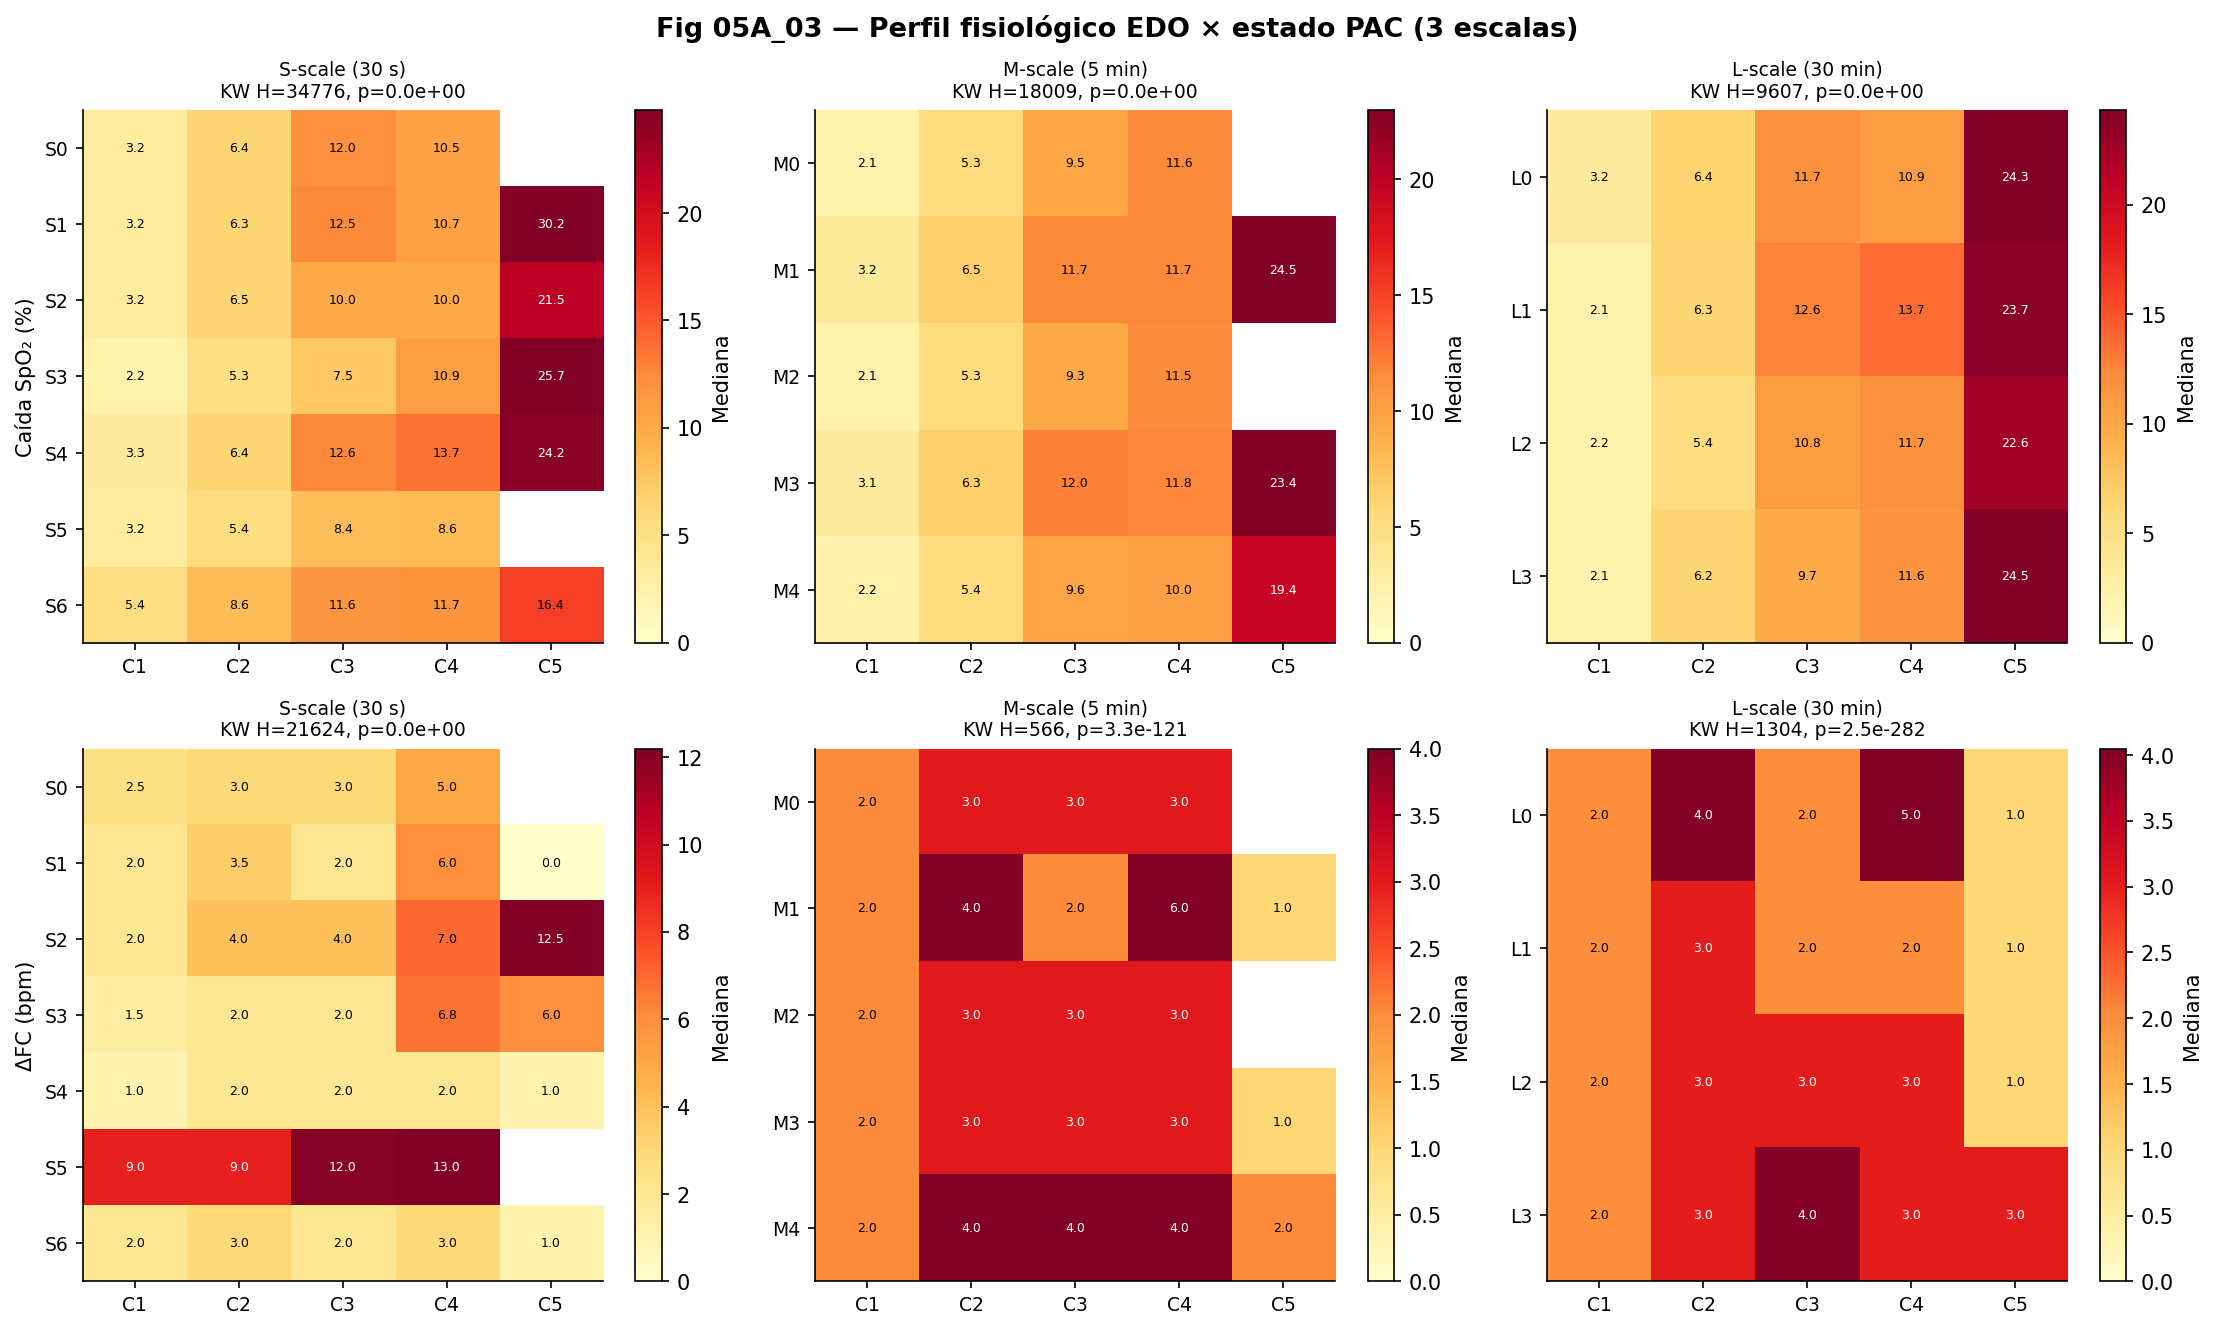

  → figuras/05A_03_perfil_fisiologico_multiscala.png


In [5]:
# A3: heatmap medianas drop_pct y delta_hr_bpm por estado × morfotipo
SCALES_DETAIL = {'s': ('state_s_label', 'S-scale (30 s)'),
                 'm': ('state_m_label', 'M-scale (5 min)'),
                 'l': ('state_l_label', 'L-scale (30 min)')}
METRICS = [('drop_pct', 'Caída SpO₂ (%)'), ('delta_hr_bpm', 'ΔFC (bpm)')]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Fig 05A_03 — Perfil fisiológico EDO × estado PAC (3 escalas)",
             fontsize=13, fontweight='bold')

for row_i, (m_col, m_label) in enumerate(METRICS):
    for col_i, (sc, (state_col, sc_label)) in enumerate(SCALES_DETAIL.items()):
        ax = axes[row_i][col_i]
        states = sorted(esm[state_col].unique(), key=lambda x: int(x[1:]))
        med_mat = np.full((len(states), len(MORPHS)), np.nan)
        for si, st in enumerate(states):
            for mi, mo in enumerate(MORPHS):
                vals = esm[(esm[state_col] == st) & (esm['morph'] == mo)][m_col].dropna()
                if len(vals) >= 5:
                    med_mat[si, mi] = vals.median()
        groups = [esm[esm[state_col] == st][m_col].dropna().values
                  for st in states if len(esm[esm[state_col] == st]) > 0]
        H, p = kruskal(*groups)
        vmax = np.nanpercentile(med_mat, 95)
        im = ax.imshow(med_mat, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
        ax.set_xticks(range(len(MORPHS)));   ax.set_xticklabels(MORPHS, fontsize=9)
        ax.set_yticks(range(len(states)));   ax.set_yticklabels(states, fontsize=9)
        if col_i == 0:
            ax.set_ylabel(m_label, fontsize=10)
        ax.set_title(f"{sc_label}\nKW H={H:.0f}, p={p:.1e}", fontsize=9)
        plt.colorbar(im, ax=ax, label='Mediana')
        for si in range(len(states)):
            for mi in range(len(MORPHS)):
                v = med_mat[si, mi]
                if not np.isnan(v):
                    ax.text(mi, si, f'{v:.1f}', ha='center', va='center', fontsize=6,
                            color='white' if v > vmax * 0.7 else 'black')
savefig('05A_03_perfil_fisiologico_multiscala.png')

### Sección A4 — Índice de acoplamiento estado-evento por noche

S-scale (30 s): estados patológicos = ['S2', 'S4', 'S6']
M-scale (5 min): estados patológicos = ['M1', 'M3']
L-scale (30 min): estados patológicos = ['L0', 'L1']

Correlaciones entre coupling indices:
       ci_s   ci_m   ci_l
ci_s  1.000  0.056 -0.113
ci_m  0.056  1.000  0.364
ci_l -0.113  0.364  1.000


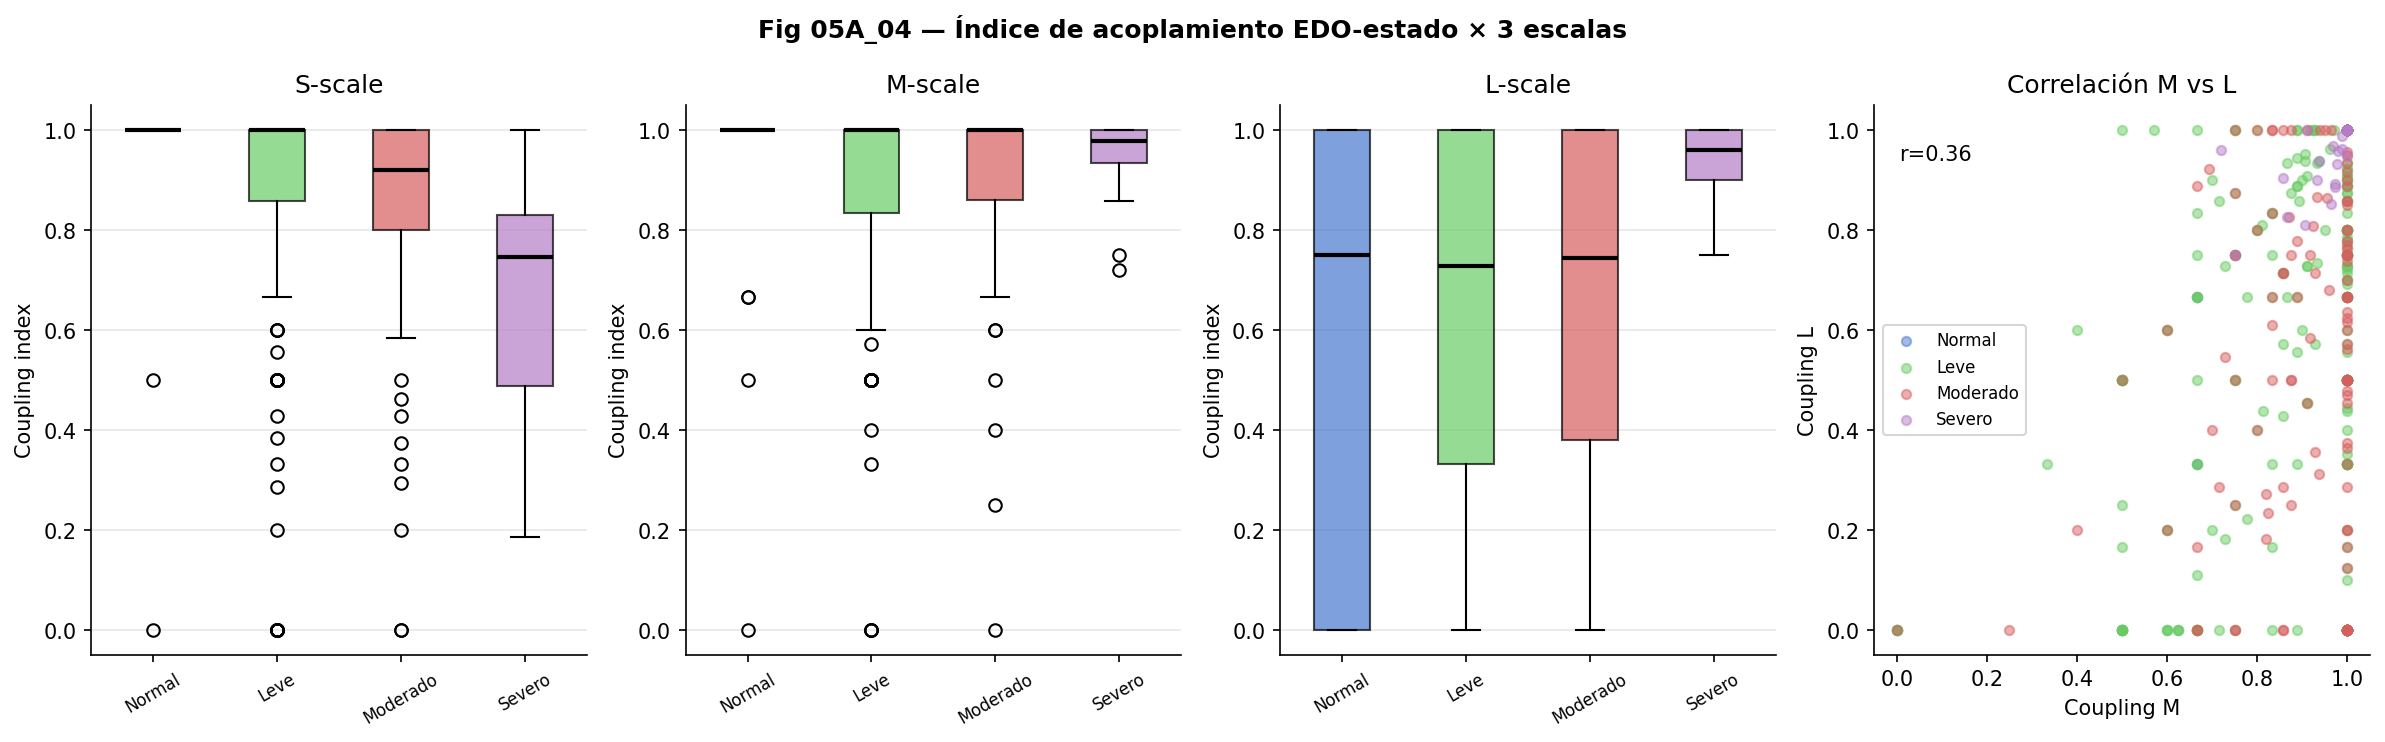

  → figuras/05A_04_coupling_multiscala.png


In [6]:
# A4: coupling index × 3 escalas
# Para cada noche: fracción de eventos severos (C4+C5) que cayeron en estado "patológico"
# Estado patológico = fracción de severos > mediana de todos los estados

severe_rate_by_scale = {}
pathological_by_scale = {}
for sc, col in SCALES.items():
    rate = esm.groupby(col)['is_severe_morph'].mean()
    severe_rate_by_scale[sc] = rate
    pathological_by_scale[sc] = rate[rate > rate.median()].index.tolist()
    print(f"{SCALE_LABELS[sc]}: estados patológicos = {sorted(pathological_by_scale[sc])}")

for sc, col in SCALES.items():
    esm[f'in_path_{sc}'] = esm[col].isin(pathological_by_scale[sc])

def coupling_all(df):
    sev = df[df['is_severe_morph']]
    if len(sev) == 0:
        return pd.Series({'ci_s': np.nan, 'ci_m': np.nan, 'ci_l': np.nan})
    return pd.Series({'ci_s': sev['in_path_s'].mean(),
                      'ci_m': sev['in_path_m'].mean(),
                      'ci_l': sev['in_path_l'].mean()})

night_ci_all = esm.groupby('night_record_id').apply(coupling_all)
# Guardar en nmf (variable de sesión)
for col in ['ci_s', 'ci_m', 'ci_l']:
    if col in nmf.columns:
        nmf = nmf.drop(columns=[col])
nmf = nmf.merge(night_ci_all.reset_index(), on='night_record_id', how='left')

# coupling_index general = ci_m (escala intermedia, la más interpretable)
nmf['coupling_index'] = nmf['ci_m']

print(f"\nCorrelaciones entre coupling indices:")
print(nmf[['ci_s','ci_m','ci_l']].corr().round(3))

SEV_ORDER  = ['Normal','Leve','Moderado','Severo']
SEV_COLORS = ['#4878CF','#6ACC65','#D65F5F','#B47CC7']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Fig 05A_04 — Índice de acoplamiento EDO-estado × 3 escalas",
             fontsize=12, fontweight='bold')
for ax, (ci_col, sc_label) in zip(axes[:3],
    [('ci_s','S-scale'),('ci_m','M-scale'),('ci_l','L-scale')]):
    data_box = [nmf[nmf['aasm_sev'] == sev][ci_col].dropna().values for sev in SEV_ORDER]
    bp = ax.boxplot(data_box, patch_artist=True, showfliers=True,
                    medianprops={'color':'black','lw':2})
    for patch, col in zip(bp['boxes'], SEV_COLORS):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_xticks(range(1, 5)); ax.set_xticklabels(SEV_ORDER, rotation=30, fontsize=8)
    ax.set_ylabel("Coupling index"); ax.set_title(sc_label); ax.grid(axis='y', alpha=0.3)
ax = axes[3]
for sev, col in zip(SEV_ORDER, SEV_COLORS):
    mask = nmf['aasm_sev'] == sev
    ax.scatter(nmf.loc[mask,'ci_m'], nmf.loc[mask,'ci_l'],
               c=col, s=20, alpha=0.5, label=sev)
ax.set_xlabel("Coupling M"); ax.set_ylabel("Coupling L")
ax.set_title("Correlación M vs L"); ax.legend(fontsize=8)
corr_ml = nmf[['ci_m','ci_l']].corr().iloc[0,1]
ax.text(0.05, 0.9, f'r={corr_ml:.2f}', transform=ax.transAxes, fontsize=10)
savefig('05A_04_coupling_multiscala.png')

---
## BLOQUE B — Secuencia Temporal y Dinámica Markoviana

### Sección B1 — Matrices de transición entre estados (cadenas de Markov)

S-scale (30 s): 462,519 transiciones | estado más frecuente: S1
M-scale (5 min): 45,900 transiciones | estado más frecuente: M0
L-scale (30 min): 7,196 transiciones | estado más frecuente: L3

Exportado: ../gold/transition_matrices.parquet  shape=(90, 5)


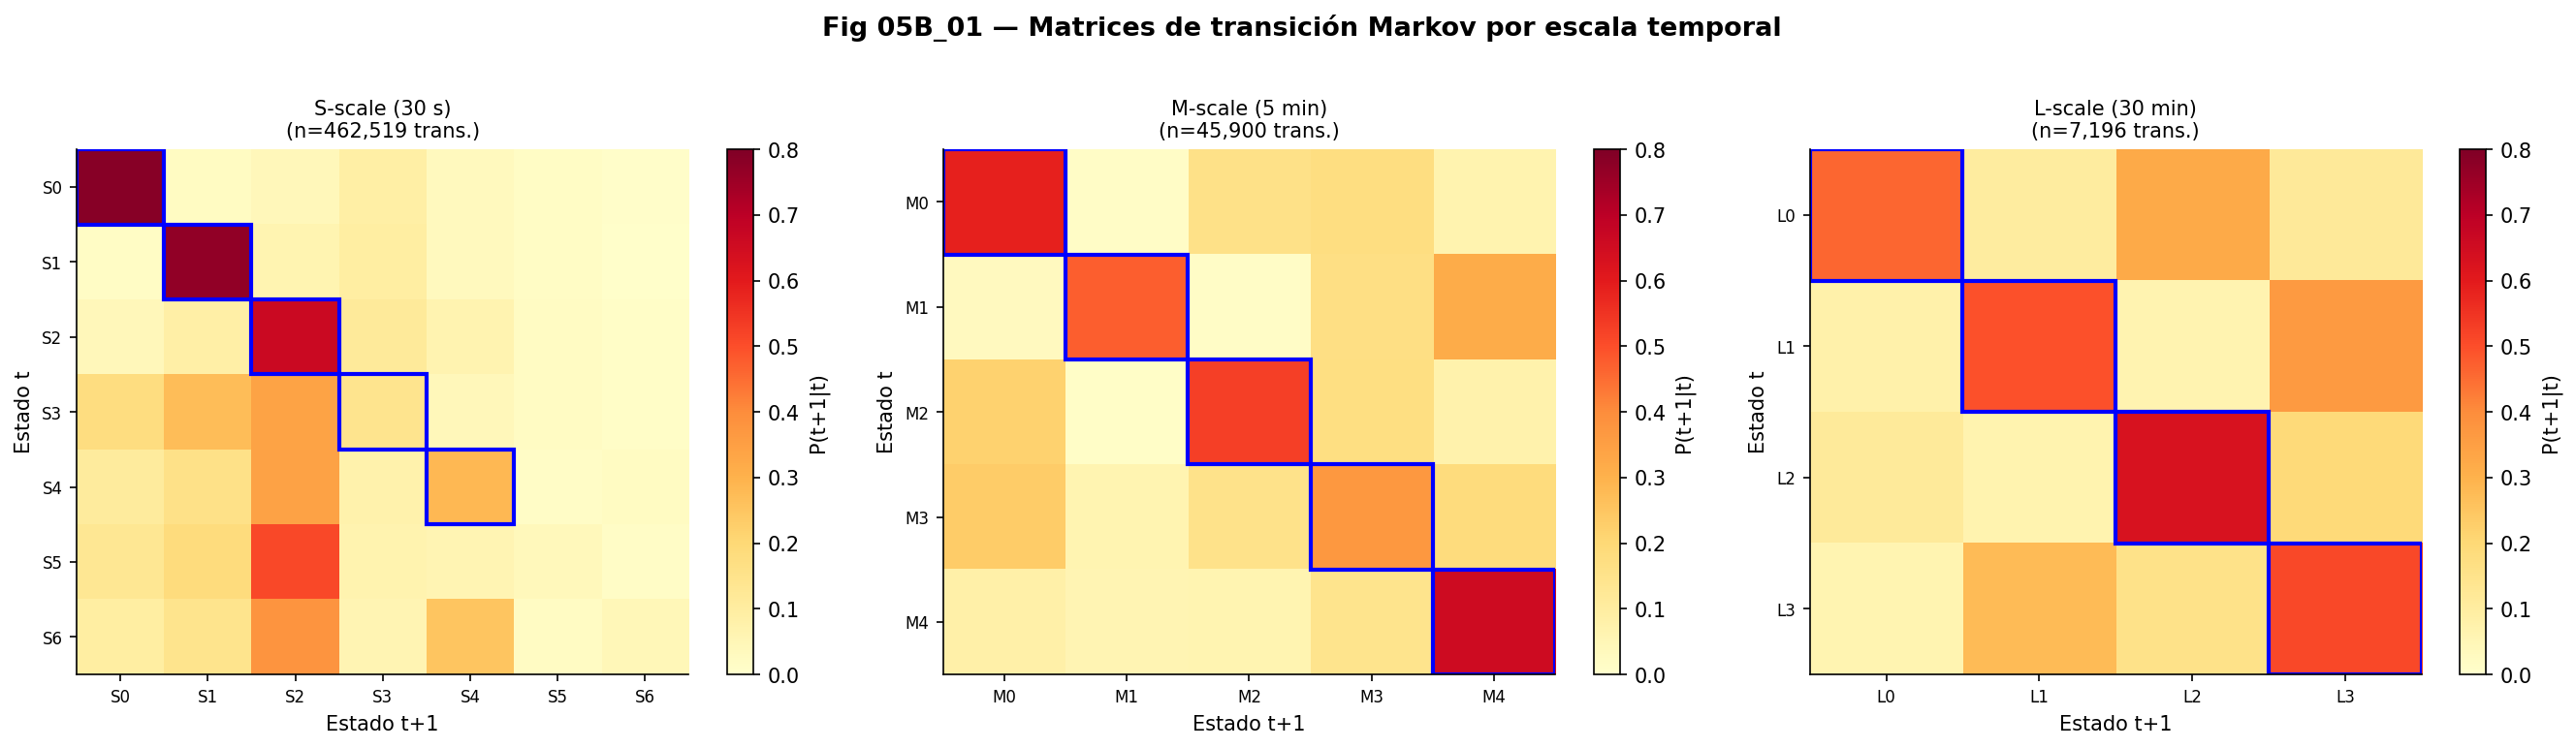

  → figuras/05B_01_markov_transicion.png


In [7]:
# B1: Matrices de transición Markov (S, M, L) — solo cohort in_strict
states_strict = states_raw[states_raw['in_strict'] == True].copy()
states_strict = states_strict[states_strict['state_label'].notna()].copy()

markov_results = {}
trans_rows = []   # para exportar a Gold

for sc in ['s', 'm', 'l']:
    sc_states = (states_strict[states_strict['scale'] == sc]
                 .sort_values(['night_record_id', 'window_idx']))
    sc_states = sc_states.copy()
    sc_states['state_next'] = sc_states.groupby('night_record_id')['state_label'].shift(-1)
    transitions = sc_states[sc_states['state_next'].notna()].copy()

    ct = pd.crosstab(transitions['state_label'], transitions['state_next'])
    all_states = sorted(set(ct.index) | set(ct.columns), key=lambda x: int(x[1:]))
    ct = ct.reindex(index=all_states, columns=all_states, fill_value=0)
    trans_prob = ct.div(ct.sum(axis=1), axis=0).fillna(0)

    def entropy_row(row):
        p = row[row > 0]
        return -np.sum(p * np.log2(p))
    trans_entropy = trans_prob.apply(entropy_row, axis=1)

    vals, vecs = eig(trans_prob.values.T)
    idx_stat = np.argmin(np.abs(vals - 1.0))
    stat_dist = np.real(vecs[:, idx_stat])
    stat_dist = stat_dist / stat_dist.sum()

    markov_results[sc] = {
        'ct': ct, 'trans_prob': trans_prob, 'entropy': trans_entropy,
        'stat_dist': pd.Series(stat_dist, index=all_states),
        'states': all_states, 'n_transitions': len(transitions)
    }
    print(f"{SCALE_LABELS[sc]}: {len(transitions):,} transiciones | "
          f"estado más frecuente: {pd.Series(stat_dist, index=all_states).idxmax()}")

    # Preparar filas para exportar
    for from_s in all_states:
        for to_s in all_states:
            trans_rows.append({'scale': sc, 'from_state': from_s, 'to_state': to_s,
                                'prob': trans_prob.loc[from_s, to_s],
                                'count': ct.loc[from_s, to_s]})

# Exportar matrices al Gold
trans_df = pd.DataFrame(trans_rows)
trans_df.to_parquet(GOLD / 'transition_matrices.parquet', index=False)
print(f"\nExportado: {GOLD / 'transition_matrices.parquet'}  shape={trans_df.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fig 05B_01 — Matrices de transición Markov por escala temporal",
             fontsize=13, fontweight='bold', y=1.02)
for ax, sc in zip(axes, ['s','m','l']):
    r = markov_results[sc]; trans = r['trans_prob']; states = r['states']
    im = ax.imshow(trans.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.8)
    ax.set_xticks(range(len(states))); ax.set_xticklabels(states, fontsize=8)
    ax.set_yticks(range(len(states))); ax.set_yticklabels(states, fontsize=8)
    ax.set_xlabel("Estado t+1"); ax.set_ylabel("Estado t")
    ax.set_title(f"{SCALE_LABELS[sc]}\n(n={r['n_transitions']:,} trans.)", fontsize=10)
    plt.colorbar(im, ax=ax, label='P(t+1|t)')
    for i in range(len(states)):
        if trans.values[i, i] > 0.1:
            ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                         fill=False, edgecolor='blue', lw=2))
savefig('05B_01_markov_transicion.png')

### Sección B2 — Contexto temporal: ventana pre — durante — post

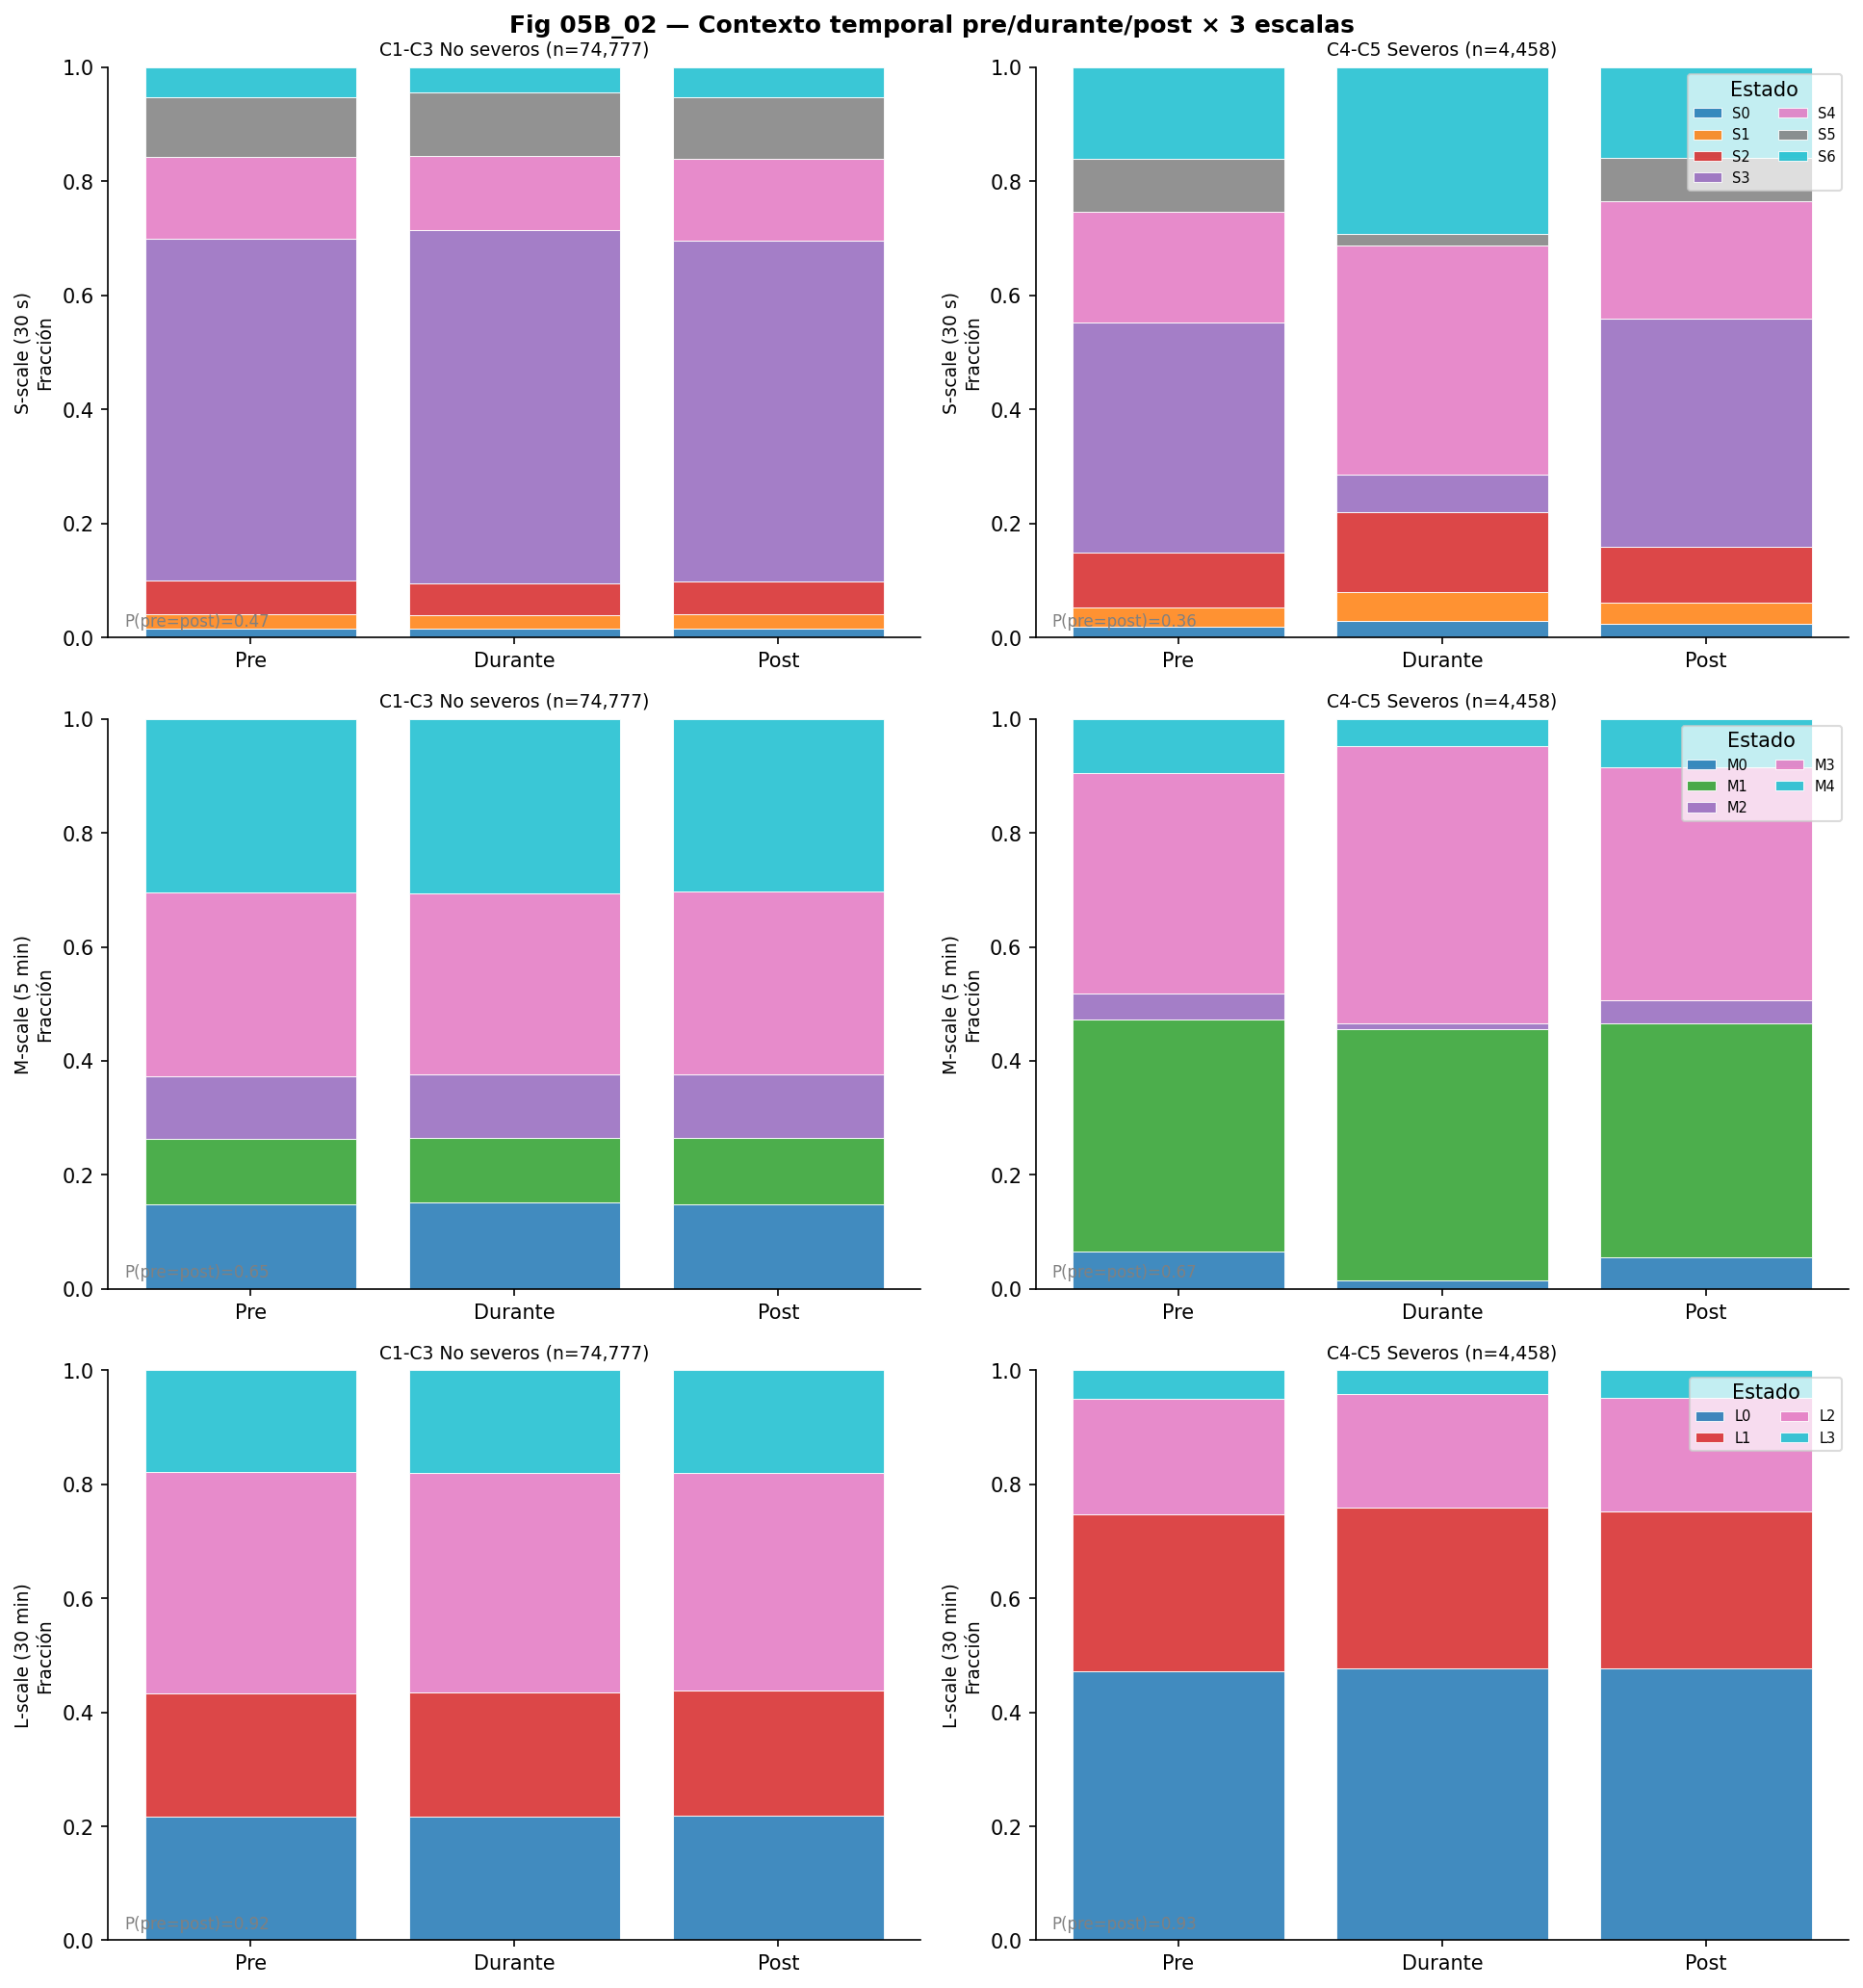

  → figuras/05B_02_contexto_multiscala.png


In [8]:
# B2: distribución de estados PAC en ventana pre/durante/post por morfotipo
SCALES_DETAIL = {'s': ('state_s_label', 'S-scale (30 s)'),
                 'm': ('state_m_label', 'M-scale (5 min)'),
                 'l': ('state_l_label', 'L-scale (30 min)')}

for sc, (col, _) in SCALES_DETAIL.items():
    esm[f'prev_{sc}'] = esm.groupby('night_record_id')[col].shift(1)
    esm[f'next_{sc}'] = esm.groupby('night_record_id')[col].shift(-1)

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
fig.suptitle("Fig 05B_02 — Contexto temporal pre/durante/post × 3 escalas",
             fontsize=12, fontweight='bold')
for row_i, (sc, (state_col, sc_label)) in enumerate(SCALES_DETAIL.items()):
    prev_col = f'prev_{sc}'; next_col = f'next_{sc}'
    esm_ctx = esm[esm[prev_col].notna() & esm[next_col].notna()].copy()
    states_all = sorted(esm[state_col].unique(), key=lambda x: int(x[1:]))
    for col_i, (is_sev, title) in enumerate([(False, 'C1-C3 No severos'), (True, 'C4-C5 Severos')]):
        ax = axes[row_i][col_i]
        g = esm_ctx[esm_ctx['is_severe_morph'] == is_sev]
        pre  = g[prev_col].value_counts(normalize=True).reindex(states_all, fill_value=0)
        dur  = g[state_col].value_counts(normalize=True).reindex(states_all, fill_value=0)
        post = g[next_col].value_counts(normalize=True).reindex(states_all, fill_value=0)
        x = np.arange(3)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(states_all)))
        bottom = np.zeros(3)
        for i, st in enumerate(states_all):
            vals = [pre[st], dur[st], post[st]]
            ax.bar(x, vals, bottom=bottom, color=colors[i], label=st,
                   alpha=0.85, edgecolor='white', lw=0.5)
            bottom += np.array(vals)
        ax.set_xticks(x); ax.set_xticklabels(['Pre','Durante','Post'], fontsize=10)
        ax.set_ylim(0, 1); ax.set_ylabel(f'{sc_label}\nFracción', fontsize=9)
        ax.set_title(f'{title} (n={len(g):,})', fontsize=9)
        if col_i == 1:
            ax.legend(loc='upper right', fontsize=7, title='Estado', ncol=2, framealpha=0.7)
        pre_eq_post = (g[prev_col] == g[next_col]).mean()
        ax.text(0.02, 0.02, f'P(pre=post)={pre_eq_post:.2f}',
                transform=ax.transAxes, fontsize=8, color='gray')
savefig('05B_02_contexto_multiscala.png')

### Sección B3 — Riesgo relativo de evento severo por estado

P(severo) marginal: 0.0573
  S-scale (30 s): S6 RR=4.9 (1313/4673 severos)
  M-scale (5 min): M1 RR=3.3 (2054/10728 severos)
  L-scale (30 min): L0 RR=2.0 (2170/18528 severos)


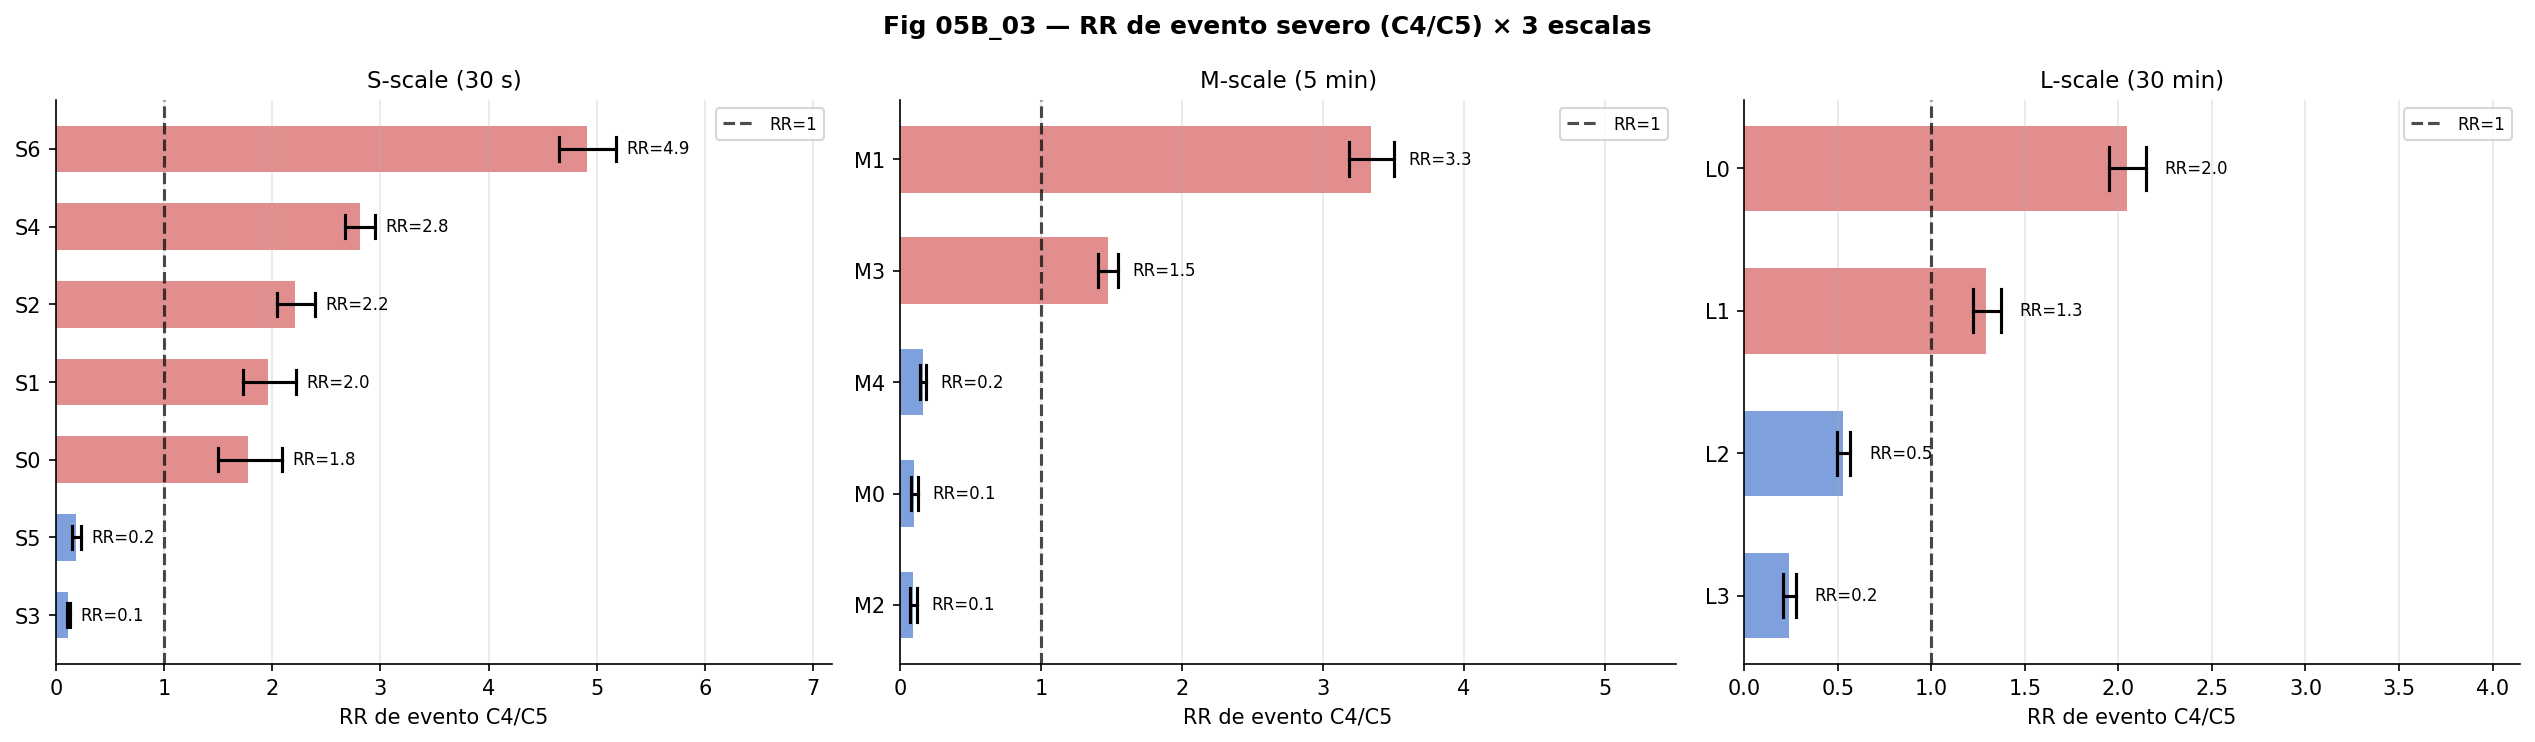

  → figuras/05B_03_riesgo_relativo_multiscala.png


In [9]:
# B3: RR de evento C4/C5 por estado PAC — 3 escalas
p_marg = esm['is_severe_morph'].mean()
print(f"P(severo) marginal: {p_marg:.4f}")

rr_by_scale = {}
for sc, (state_col, sc_label) in SCALES_DETAIL.items():
    rr = esm.groupby(state_col).agg(
        n=('is_severe_morph','count'),
        n_severe=('is_severe_morph','sum'),
        p_severe=('is_severe_morph','mean')
    ).reset_index()
    rr.columns = ['state','n','n_severe','p_severe']
    rr['RR'] = rr['p_severe'] / p_marg
    z = 1.96
    rr['se_log'] = np.sqrt((1 - rr['p_severe']) / (rr['n_severe'] + 0.5) +
                            (1 - p_marg) / (esm['is_severe_morph'].sum() + 0.5))
    rr['RR_lo'] = np.exp(np.log(rr['RR']) - z * rr['se_log'])
    rr['RR_hi'] = np.exp(np.log(rr['RR']) + z * rr['se_log'])
    rr_by_scale[sc] = rr
    top = rr.nlargest(1,'RR').iloc[0]
    print(f"  {sc_label}: {top['state']} RR={top['RR']:.1f} ({top['n_severe']:.0f}/{top['n']:.0f} severos)")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Fig 05B_03 — RR de evento severo (C4/C5) × 3 escalas",
             fontsize=12, fontweight='bold')
for ax, (sc, (state_col, sc_label)) in zip(axes, SCALES_DETAIL.items()):
    rr = rr_by_scale[sc].sort_values('RR')
    y_pos = range(len(rr))
    ax.barh(list(y_pos), rr['RR'], 0.6,
            color=['#D65F5F' if r > 1 else '#4878CF' for r in rr['RR']], alpha=0.7)
    for i, (_, row) in enumerate(rr.iterrows()):
        ax.plot([row['RR_lo'], row['RR_hi']], [i, i], 'k-', lw=1.5)
        for x_ci in [row['RR_lo'], row['RR_hi']]:
            ax.plot([x_ci]*2, [i-0.15, i+0.15], 'k-', lw=1.5)
    ax.axvline(1.0, color='black', ls='--', lw=1.5, alpha=0.7, label='RR=1')
    ax.set_yticks(list(y_pos)); ax.set_yticklabels(rr['state'].tolist())
    ax.set_xlabel("RR de evento C4/C5"); ax.set_title(sc_label, fontsize=11)
    ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(rr.iterrows()):
        ax.text(row['RR_hi'] + 0.1, i, f"RR={row['RR']:.1f}", va='center', fontsize=8)
    ax.set_xlim(0, rr['RR_hi'].max() + 2)
savefig('05B_03_riesgo_relativo_multiscala.png')

### Sección B4 — Resiliencia fisiológica post-evento

  S-scale (30 s): resiliente=43.3%, colapsado=40.2%
  M-scale (5 min): resiliente=12.3%, colapsado=80.4%
  L-scale (30 min): resiliente=1.3%, colapsado=74.5%


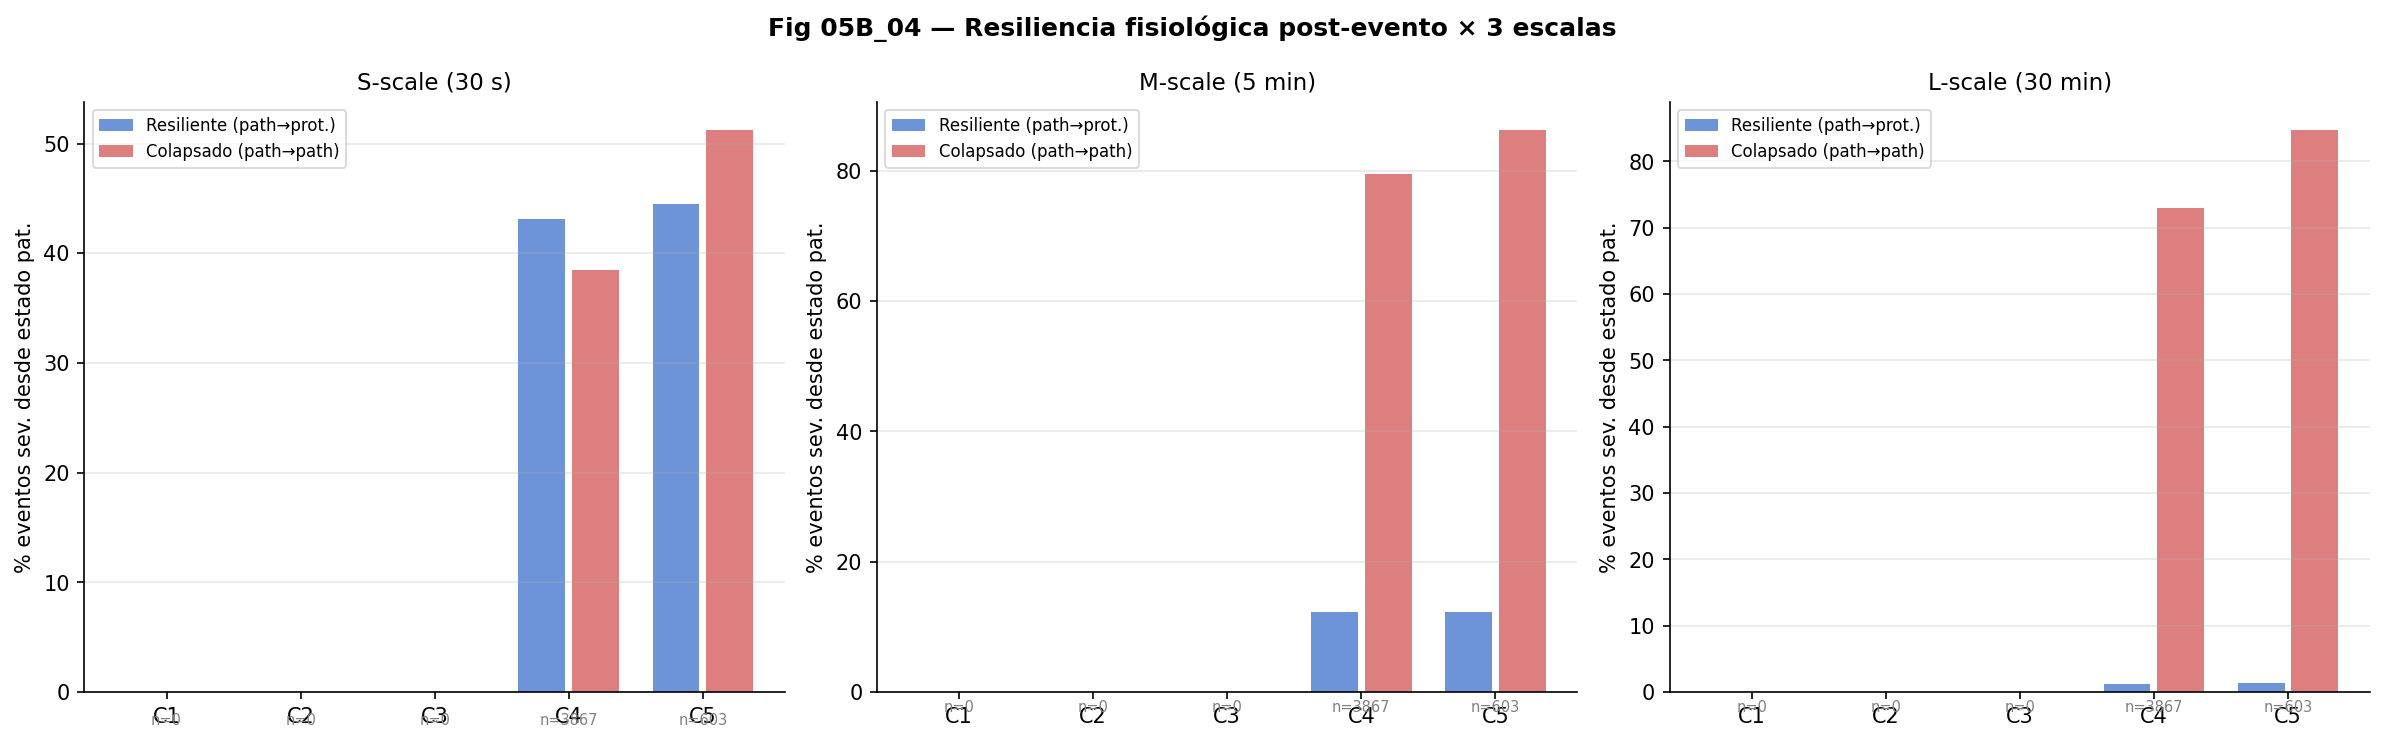

  → figuras/05B_04_resiliencia_multiscala.png


In [10]:
# B4: tras un evento severo en estado patológico, ¿el siguiente estado es protector o sigue siendo patológico?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fig 05B_04 — Resiliencia fisiológica post-evento × 3 escalas",
             fontsize=12, fontweight='bold')
for ax, (sc, (state_col, sc_label)) in zip(axes, SCALES_DETAIL.items()):
    next_col = f'next_{sc}'
    if next_col not in esm.columns:
        esm[next_col] = esm.groupby('night_record_id')[state_col].shift(-1)
    path_states = pathological_by_scale[sc]
    esm[f'in_path_{sc}']      = esm[state_col].isin(path_states)
    esm[f'next_in_path_{sc}'] = esm[next_col].isin(path_states)
    sev_ev = esm[esm['is_severe_morph'] & esm[next_col].notna()].copy()
    sev_ev['resilient'] = sev_ev[f'in_path_{sc}'] & ~sev_ev[f'next_in_path_{sc}']
    sev_ev['collapsed'] = sev_ev[f'in_path_{sc}'] &  sev_ev[f'next_in_path_{sc}']
    res = sev_ev.groupby('morph').agg(
        n=('resilient','count'),
        pct_resilient=('resilient','mean'),
        pct_collapsed=('collapsed','mean')
    ).reset_index()
    x = np.arange(len(MORPHS))
    md_r = res.set_index('morph').reindex(MORPHS, fill_value=0)
    ax.bar(x - 0.2, md_r['pct_resilient'] * 100, 0.35,
           label='Resiliente (path→prot.)', color='#4878CF', alpha=0.8)
    ax.bar(x + 0.2, md_r['pct_collapsed'] * 100, 0.35,
           label='Colapsado (path→path)', color='#D65F5F', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(MORPHS)
    ax.set_ylabel("% eventos sev. desde estado pat."); ax.set_title(sc_label, fontsize=11)
    ax.legend(fontsize=8, framealpha=0.7); ax.grid(axis='y', alpha=0.3)
    for i, morph in enumerate(MORPHS):
        n = md_r.loc[morph,'n'] if morph in md_r.index else 0
        ax.text(i, -3, f'n={n:.0f}', ha='center', fontsize=7, color='gray')
    total_n = res['n'].sum()
    mean_r = (res['n'] * res['pct_resilient']).sum() / total_n
    mean_c = (res['n'] * res['pct_collapsed']).sum() / total_n
    print(f"  {sc_label}: resiliente={mean_r:.1%}, colapsado={mean_c:.1%}")
savefig('05B_04_resiliencia_multiscala.png')

### Sección B5 — Trayectoria integrada de la noche — fenotipado nocturno

Vector de noche completo: 513 noches
Varianza explicada: PC1=0.336, PC2=0.236, PC3=0.142
PC1 loadings: {'frac_state_m_M1': np.float64(-0.442), 'frac_state_m_M3': np.float64(0.077), 'pct_severe': np.float64(-0.471), 'mean_ari': np.float64(0.35), 'coupling_index': np.float64(0.011), 'n_transitions_state_m': np.float64(0.492), 'entropy_state_m': np.float64(0.46)}

Perfil de clusters (medianas):
       frac_state_m_M1  frac_state_m_M3  pct_severe  mean_ari  coupling_index  n_transitions_state_m  entropy_state_m
clust                                                                                                                
0                0.028            0.120       0.031     0.522            0.75                   29.0            1.497
1                0.035            0.227       0.050     0.493            1.00                   42.0            1.933
2                0.781            0.031       0.361     0.284            1.00                    6.0            1.122

P(cluster | aa

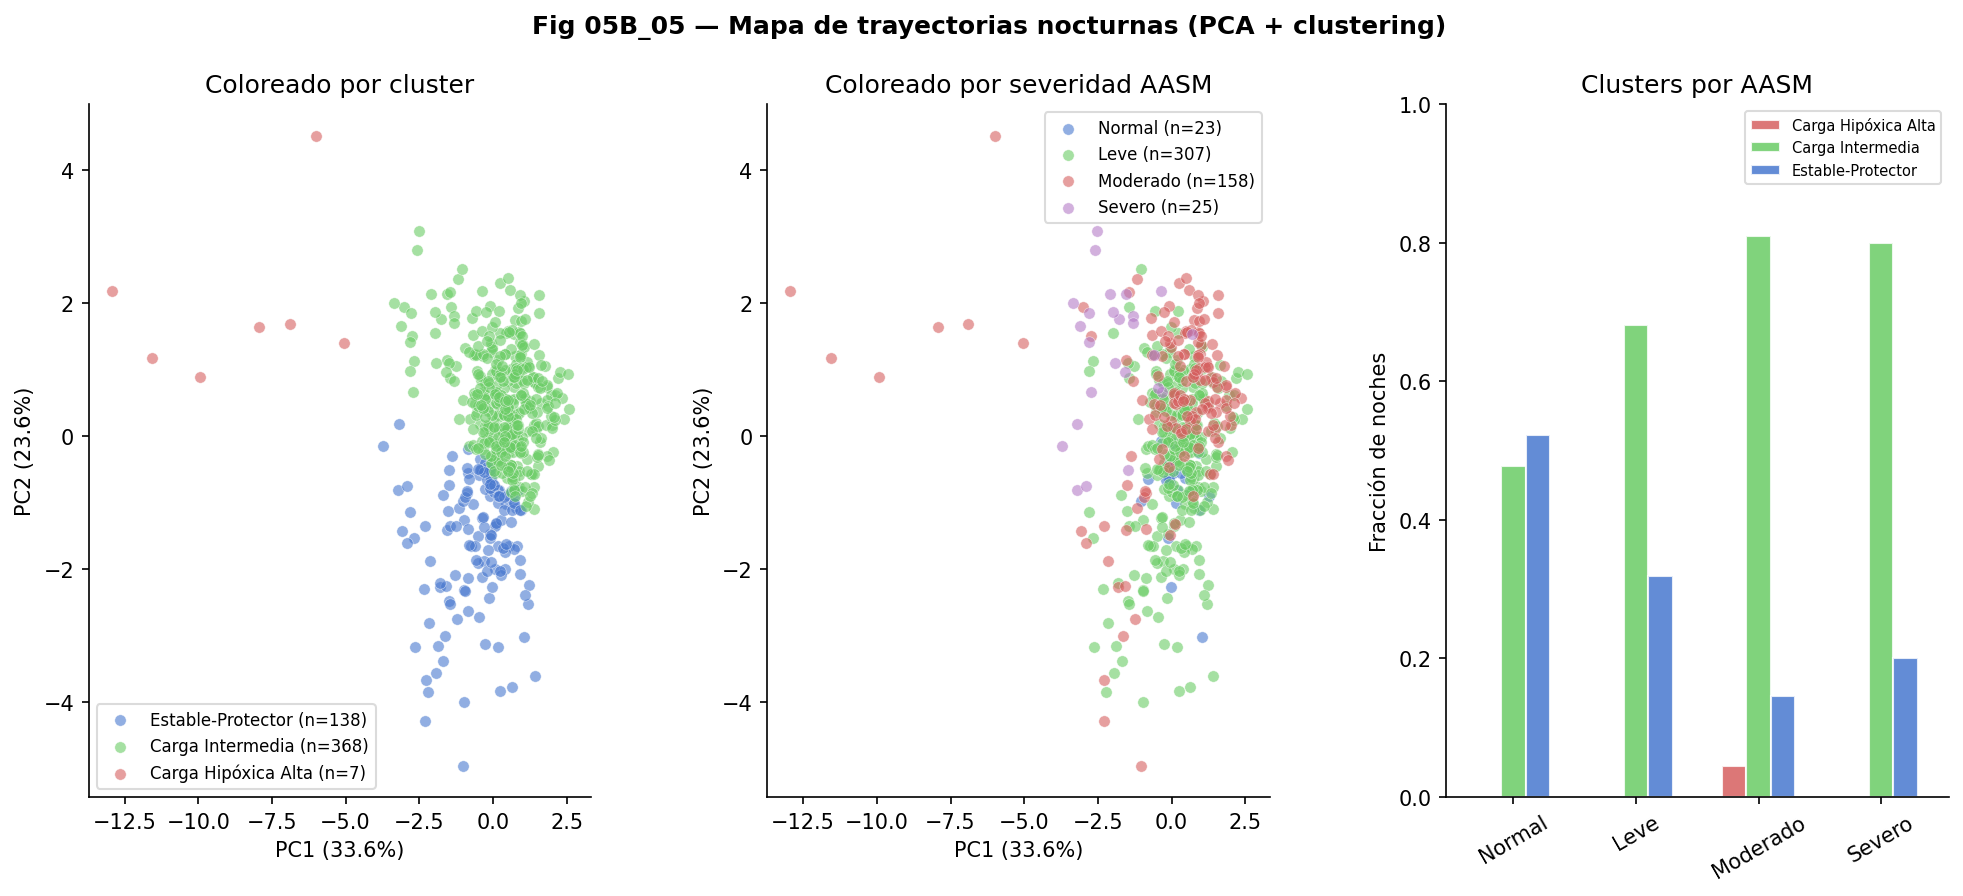

  → figuras/05B_05_trayectorias_nocturnas.png


In [13]:
# B5: PCA + KMeans sobre perfil nocturno combinado
# pct_severe: fracción de eventos C4+C5 por noche (desde esm in_strict)
sev_by_night = esm.groupby('night_record_id')['is_severe_morph'].mean().rename('pct_severe')
if 'pct_severe' in nmf.columns:
    nmf = nmf.drop(columns=['pct_severe'])
nmf = nmf.merge(sev_by_night.reset_index(), on='night_record_id', how='left')

# TRAJ_FEATS: columnas con varianza real (M5/M6/M7 son todas cero → excluidas)
# Usamos M1 (máxima asociación con T90), M3 (asociación con ARI negativa), más métricas de sesión
TRAJ_FEATS = ['frac_state_m_M1', 'frac_state_m_M3', 'pct_severe',
              'mean_ari', 'coupling_index', 'n_transitions_state_m', 'entropy_state_m']

# Filtrar noches con todas las features disponibles
meta_cols = [c for c in ['night_record_id', 'user_id', 'aasm_sev'] if c in nmf.columns]
tdf = nmf[meta_cols + TRAJ_FEATS].dropna().copy()
print(f"Vector de noche completo: {len(tdf)} noches")

X    = tdf[TRAJ_FEATS].values
X_sc = StandardScaler().fit_transform(X)

pca    = PCA(n_components=3, random_state=42)
X_pca  = pca.fit_transform(X_sc)
ev     = pca.explained_variance_ratio_
tdf['PC1'] = X_pca[:, 0]; tdf['PC2'] = X_pca[:, 1]
print(f"Varianza explicada: PC1={ev[0]:.3f}, PC2={ev[1]:.3f}, PC3={ev[2]:.3f}")
print("PC1 loadings:", dict(zip(TRAJ_FEATS, pca.components_[0].round(3))))

kmeans     = KMeans(n_clusters=3, random_state=42, n_init=10)
tdf['clust'] = kmeans.fit_predict(X_sc)
cp = tdf.groupby('clust')[TRAJ_FEATS].median()
co = cp['pct_severe'].sort_values().index.tolist()
cnames = {co[0]: 'Estable-Protector', co[1]: 'Carga Intermedia', co[2]: 'Carga Hipóxica Alta'}
tdf['night_traj_name'] = tdf['clust'].map(cnames)
print("\nPerfil de clusters (medianas):")
print(cp.round(3).to_string())
print("\nP(cluster | aasm_sev):")
print(pd.crosstab(tdf['aasm_sev'], tdf['night_traj_name'], normalize='index').round(3))

cc  = {'Estable-Protector':'#4878CF','Carga Intermedia':'#6ACC65','Carga Hipóxica Alta':'#D65F5F'}
sc2 = {'Normal':'#4878CF','Leve':'#6ACC65','Moderado':'#D65F5F','Severo':'#B47CC7'}
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Fig 05B_05 — Mapa de trayectorias nocturnas (PCA + clustering)",
             fontsize=12, fontweight='bold')
gs = mgs.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
for cn, col in cc.items():
    m = tdf['night_traj_name'] == cn
    ax1.scatter(tdf.loc[m,'PC1'], tdf.loc[m,'PC2'], c=col, s=30, alpha=0.6,
                label=f'{cn} (n={m.sum()})', edgecolors='white', linewidths=0.3)
ax1.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax1.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax1.set_title("Coloreado por cluster"); ax1.legend(fontsize=8, framealpha=0.7)

ax2 = fig.add_subplot(gs[1])
for sv, col in sc2.items():
    m = tdf['aasm_sev'] == sv
    ax2.scatter(tdf.loc[m,'PC1'], tdf.loc[m,'PC2'], c=col, s=30, alpha=0.6,
                label=f'{sv} (n={m.sum()})', edgecolors='white', linewidths=0.3)
ax2.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax2.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax2.set_title("Coloreado por severidad AASM"); ax2.legend(fontsize=8, framealpha=0.7)

ax3 = fig.add_subplot(gs[2])
ctp = pd.crosstab(tdf['aasm_sev'], tdf['night_traj_name'], normalize='index')
ctp.reindex(['Normal','Leve','Moderado','Severo']).plot(
    kind='bar', ax=ax3, color=[cc.get(c,'#aaa') for c in ctp.columns],
    edgecolor='white', width=0.6, alpha=0.85)
ax3.set_ylim(0, 1); ax3.set_ylabel("Fracción de noches")
ax3.set_title("Clusters por AASM"); ax3.set_xlabel("")
ax3.tick_params(axis='x', rotation=30); ax3.legend(fontsize=7, framealpha=0.7)
savefig('05B_05_trayectorias_nocturnas.png')

# Guardar cluster en nmf para exportación
if 'night_traj_cluster' in nmf.columns:           # ← agregar
    nmf = nmf.drop(columns=['night_traj_cluster']) # ← agregar

# Guardar cluster en nmf para exportación
nmf = nmf.merge(tdf[['night_record_id','night_traj_name']].rename(
    columns={'night_traj_name':'night_traj_cluster'}), on='night_record_id', how='left')

---
## Export al Gold

In [14]:
# Exportar nmf actualizado (+ coupling_index, pct_severe, night_traj_cluster)
out_nmf = GOLD / 'night_multiscale_features.parquet'
nmf.to_parquet(out_nmf, index=False)
print(f"night_multiscale_features.parquet: {nmf.shape}  → {out_nmf}")

nb05_cols = [c for c in ['coupling_index','ci_s','ci_m','ci_l',
                          'pct_severe','night_traj_cluster'] if c in nmf.columns]
print(f"Columnas NB05 incorporadas: {nb05_cols}")

# Verificación
nmf_fin  = pd.read_parquet(GOLD / 'night_multiscale_features.parquet')
esm_fin  = pd.read_parquet(GOLD / 'event_states_multiscale.parquet')
trans_fin = pd.read_parquet(GOLD / 'transition_matrices.parquet')

print(f"\n=== Verificación Gold ===")
print(f"night_multiscale_features : {nmf_fin.shape}")
print(f"event_states_multiscale   : {esm_fin.shape}")
print(f"transition_matrices       : {trans_fin.shape}")
print(f"  escalas en trans: {trans_fin['scale'].unique()}")
print("\n=== NB05 completado ===")

night_multiscale_features.parquet: (560, 50)  → ../gold/night_multiscale_features.parquet
Columnas NB05 incorporadas: ['coupling_index', 'ci_s', 'ci_m', 'ci_l', 'pct_severe', 'night_traj_cluster']

=== Verificación Gold ===
night_multiscale_features : (560, 50)
event_states_multiscale   : (85258, 48)
transition_matrices       : (90, 5)
  escalas en trans: ['s' 'm' 'l']

=== NB05 completado ===


## NB05 — EDO × Estados PAC: reporte de resultados

### Corpus analizado

80.353 eventos (cohort in_strict, 12 pacientes, 560 noches). La distribución morfotípica es: C1 65%, C2 25%, C3 4.2%, C4 4.9%, C5 0.8%. Los eventos severos (C4+C5) son el **5.73%** del total — son raros pero clínicamente relevantes. La cohorte es predominantemente Leve (334 noches), con 160 Moderado y 25 Severo.

---

### BLOQUE A — ¿En qué estado PAC ocurre cada morfotipo?

**El estado en que ocurre un evento sí predice parcialmente su morfotipo** (V de Cramér: S=0.354, M=0.230, L=0.196). La asociación es mayor en la escala corta, lo que tiene sentido: el morfotipo es un fenómeno de segundos, y la microdinámica (S) lo captura mejor que la arquitectura nocturna (L).

Los estados con mayor acumulación de eventos C4+C5 (los "estados patológicos") son:

| Escala | Estados patológicos |
|---|---|
| S (30 s) | S2, S4, S6 |
| M (5 min) | M1, M3 |
| L (30 min) | L0, L1 |

Esto es coherente con NB04: S4 y M1 ya aparecían como los estados más asociados con AHI y carga hipóxica.

**Hallazgo sorpresivo en el acoplamiento por escala:** la correlación entre el coupling index de escala S y el de escala M es prácticamente nula (r=0.056). En cambio, M y L tienen r=0.364. Esto significa que el acoplamiento morfotipo-estado a nivel de microdinámica (minuto a minuto) y el acoplamiento a nivel de arquitectura nocturna son fenómenos casi independientes — un paciente puede tener alta concentración de eventos severos en estados patológicos de escala S sin que eso se refleje en las escalas más largas, y viceversa.

---

### BLOQUE B — Dinámica temporal y riesgo por estado

**B1 — Matrices de Markov**

Las cadenas de Markov revelan qué estado sigue a cuál. Los estados más frecuentes en distribución estacionaria son S1 (escala S), M0 (escala M) y L3 (escala L) — los "atractores" del sistema. El hecho de que M0 y L3 sean los más frecuentes es importante: en NB04 vimos que M0 y L3 estaban negativamente correlacionados con AHI, es decir, son estados "saludables" o de recuperación. El sistema tiende a volver a ellos.

**B3 — Riesgo relativo de evento severo por estado**

Este es uno de los hallazgos más concretos del notebook. Con una P(severo) marginal del 5.73%:

| Escala | Estado de mayor riesgo | RR | Interpretación |
|---|---|---|---|
| S (30 s) | **S6** | **4.9×** | Casi 5 veces más probable que ocurra C4/C5 |
| M (5 min) | **M1** | **3.3×** | Sueño Ligero Estable triplica el riesgo |
| L (30 min) | **L0** | **2.0×** | Arquitectura de "noche hipóxica" duplica el riesgo |

S6 con RR=4.9 es el hallazgo más llamativo: si el sistema PAC marca S6, el próximo evento tiene casi 5 veces más probabilidad de ser morfológicamente severo. Es un marcador de riesgo inminente a nivel de microdinámica.

**B4 — Resiliencia post-evento**

Pregunta: después de un evento severo que ocurrió en estado patológico, ¿el estado siguiente es protector o el sistema sigue en estado patológico?

| Escala | Resiliente (sale del estado patológico) | Colapsado (se queda) |
|---|---|---|
| S (30 s) | **43.3%** | 40.2% |
| M (5 min) | 12.3% | **80.4%** |
| L (30 min) | 1.3% | **74.5%** |

La lectura es clínicamente muy relevante: a escala de microdinámica (segundos), el sistema todavía tiene capacidad de salir del estado patológico casi la mitad de las veces. Pero a escala de 5 minutos, 8 de cada 10 veces el estado patológico persiste. Y a escala de arquitectura nocturna, prácticamente nunca se recupera (1.3%). **El sistema hipóxico tiene inercia que crece con la escala temporal.** Un evento severo aislado puede recuperarse a escala corta, pero si la arquitectura de la noche está en L0, ese estado va a mantenerse durante horas.

---

### BLOQUE B5 — Fenotipos nocturnos integrados (PCA + KMeans)

Con 513 noches y 7 features combinadas (fracción M1, fracción M3, pct_severe, ARI, coupling_index, transiciones, entropía), el PCA identifica dos ejes principales:

**PC1 (33.6% de varianza)** opone dos tipos de noche:
- Noches con mucho M1 (sueño ligero hipóxico), alta severidad morfotípica y bajo ARI → carga hipóxica pasiva
- Noches dinámicas (muchas transiciones, alta entropía) con ARI alto → reactividad autonómica activa

**Los tres clusters resultantes:**

**Estable-Protector** (Cluster 0): M1 casi ausente (2.8%), sueño profundo presente (M3=12%), solo 3.1% eventos severos, ARI=0.522 (el más alto de los tres), pocas transiciones pero con cierta variedad de estados, coupling_index=0.75. Es la noche "sana" dentro de la cohorte SAOS.

**Carga Intermedia** (Cluster 1): M3 elevado (22.7%), la mayor entropía (1.933) y más transiciones (42), ARI=0.493, 5% eventos severos, coupling_index=1.00. Es el cluster más dinámico — el sistema aún cambia de estado con frecuencia. Paradójicamente tiene el mayor M3 (sueño profundo) pero también la mayor actividad de transición.

**Carga Hipóxica Alta** (Cluster 2): el cluster más extremo. M1=78.1% — casi toda la noche en sueño ligero hipóxico continuo —, 36.1% de eventos severos, **ARI=0.284** (el más bajo de los tres, prácticamente la mitad que los otros clusters), solo 6 transiciones y baja entropía. La noche es plana, monótona, sin dinámica. El sistema no sale de M1.

**La distribución de clusters por severidad AASM revela algo inesperado:**

| Cluster | Normal | Leve | Moderado | Severo |
|---|---|---|---|---|
| Estable-Protector | **52.2%** | 31.9% | 14.6% | 20.0% |
| Carga Intermedia | 47.8% | **68.1%** | **81.0%** | **80.0%** |
| Carga Hipóxica Alta | 0% | 0% | **4.4%** | 0% |

El cluster "Carga Hipóxica Alta" aparece únicamente en el 4.4% de los pacientes **Moderados** y en 0% de los Severos. Esto es contraintuitivo: los pacientes con AHI más alto no caen en el peor fenotipo nocturno según PAC. Una interpretación posible: los Severos todavía tienen reactividad autonómica residual (ARI más alto que el cluster 2) que les genera algo de dinámica. El subgrupo Moderado con "Carga Hipóxica Alta" sería el fenotipo fisiológicamente más preocupante de la cohorte: severidad convencional moderada pero arquitectura nocturna completamente colapsada, sin respuesta autonómica y sin variedad de estados.

---

### Conclusión integradora

NB05 cierra el círculo entre morfología del evento, contexto dinámico y trayectoria nocturna. Los tres hallazgos más sólidos son:

**1. El estado S6 es un marcador de riesgo inminente** (RR=4.9): cuando el sistema PAC entra en S6, el próximo evento tiene casi 5 veces más probabilidad de ser morfológicamente severo. Es el estado con mayor poder predictivo a nivel de microdinámica.

**2. La inercia del sistema hipóxico crece con la escala temporal**: a 30 segundos el sistema puede recuperarse (43% de veces), a 5 minutos casi no puede (80% colapsado), y a escala de arquitectura nocturna prácticamente nunca sale del estado patológico (1.3% de recuperación). Esto sugiere que las intervenciones terapéuticas necesitan actuar antes de que el sistema quede atrapado en M1 o L0.

**3. Hay un subgrupo de SAOS Moderado con fenotipo nocturno de "Carga Hipóxica Alta"** que no aparece en los Severos: noches monótonas en M1, sin transiciones, sin reactividad autonómica (ARI bajo). Este subgrupo podría representar el grupo clínicamente más importante de identificar, porque el AHI convencional los cataloga como moderados pero su arquitectura nocturna es la más disfuncional de toda la cohorte.